In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

## Task 1: Data Prep & Baseline

Sample count: 333, feature count: 7
The three species are: ['Adelie', 'Chinstrap', 'Gentoo']


C:\Users\user\AppData\Local\Temp\ipykernel_20612\1712755246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=penguins, x="species", palette="PiYG")


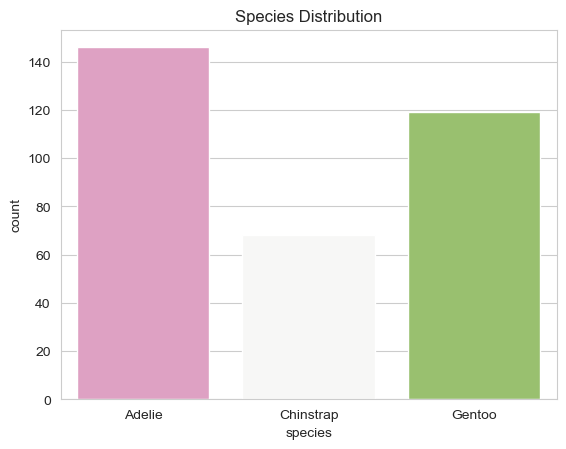

Numerical columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical columns: ['species', 'island', 'sex']


In [25]:
penguins = sns.load_dataset("penguins").dropna()
print(f"Sample count: {penguins.shape[0]}, feature count: {penguins.shape[1]}")
print(f"The three species are: {penguins["species"].unique().tolist()}")
sns.countplot(data=penguins, x="species", palette="PiYG")
plt.title("Species Distribution")
plt.show()
numerical=penguins.select_dtypes(include="float").columns.to_list()
print(f"Numerical columns: {numerical}")
categorical=penguins.select_dtypes(include=["object","category"]).columns.to_list()
print(f"Categorical columns: {categorical}")

In [26]:
le=LabelEncoder()
penguins["species"]=le.fit_transform(penguins["species"])
penguins=pd.get_dummies(penguins, columns=["island", "sex"], drop_first=True)
print(penguins.head())

   species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0        0            39.1           18.7              181.0       3750.0   
1        0            39.5           17.4              186.0       3800.0   
2        0            40.3           18.0              195.0       3250.0   
4        0            36.7           19.3              193.0       3450.0   
5        0            39.3           20.6              190.0       3650.0   

   island_Dream  island_Torgersen  sex_Male  
0         False              True      True  
1         False              True     False  
2         False              True     False  
4         False              True     False  
5         False              True      True  


In [27]:
X=penguins.drop("species",axis=1)
y=penguins["species"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
ss=StandardScaler()
X_train_scaled=ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)
lr=LogisticRegression(max_iter=10000, multi_class='multinomial')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [28]:
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.4f}")
print("-" * 30)
print("Full Classification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.9851
------------------------------
Full Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



Model Performance Analysis: Our Logistic Regression model achieved an impressive overall accuracy of 98.5%, demonstrating excellent predictive capabilities. The analysis of the results indicates that the Gentoo species was the easiest to classify, reaching a perfect F1-score of 1.00, likely due to its distinct physical characteristics (such as larger body mass and flipper length) compared to the other species. Conversely, the Adelie and Chinstrap species were the most "challenging" to distinguish due to their significant overlap in physical measurements and shared habitats; this resulted in the Chinstrap species having the lowest F1-score (0.97). Overall, the model proves to be highly effective at differentiating between all three species with minimal error.

## Task 2: Algorithm Comparison

In [29]:
models = {
    "GaussianNB": GaussianNB(),
    "Linear SVM": SVC(kernel="linear", probability=True),
    "RBF SVM": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
comparison_list = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    comparison_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
comparison_df = pd.DataFrame(comparison_list).set_index("Model")
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)
print(comparison_df)

               Accuracy  Precision    Recall  F1 Score
Model                                                 
Random Forest  1.000000   1.000000  1.000000  1.000000
Linear SVM     0.985075   0.986070  0.985075  0.985201
RBF SVM        0.985075   0.986070  0.985075  0.985201
Decision Tree  0.955224   0.957214  0.955224  0.955212
GaussianNB     0.776119   0.851175  0.776119  0.760229


Among the evaluated models, Random Forest performed best with a perfect 1.00 F1-score, as its ensemble nature effectively eliminates individual tree errors and captures complex patterns in the data. Linear and RBF SVM followed closely (~98.5%), proving that the species are mostly well-separated in the feature space. The most notable surprise was GaussianNB's significantly lower performance (~77%), which occurs because it assumes features like bill length and body mass are independent, whereas in reality, these physical traits are highly correlated in penguins. Ultimately, while most models succeed due to the high-quality features of the dataset, tree-based ensemble methods provide the most robust results by avoiding the overfitting issues seen in a single Decision Tree.

## Task 3: Confusion Matrices & ROC Curves

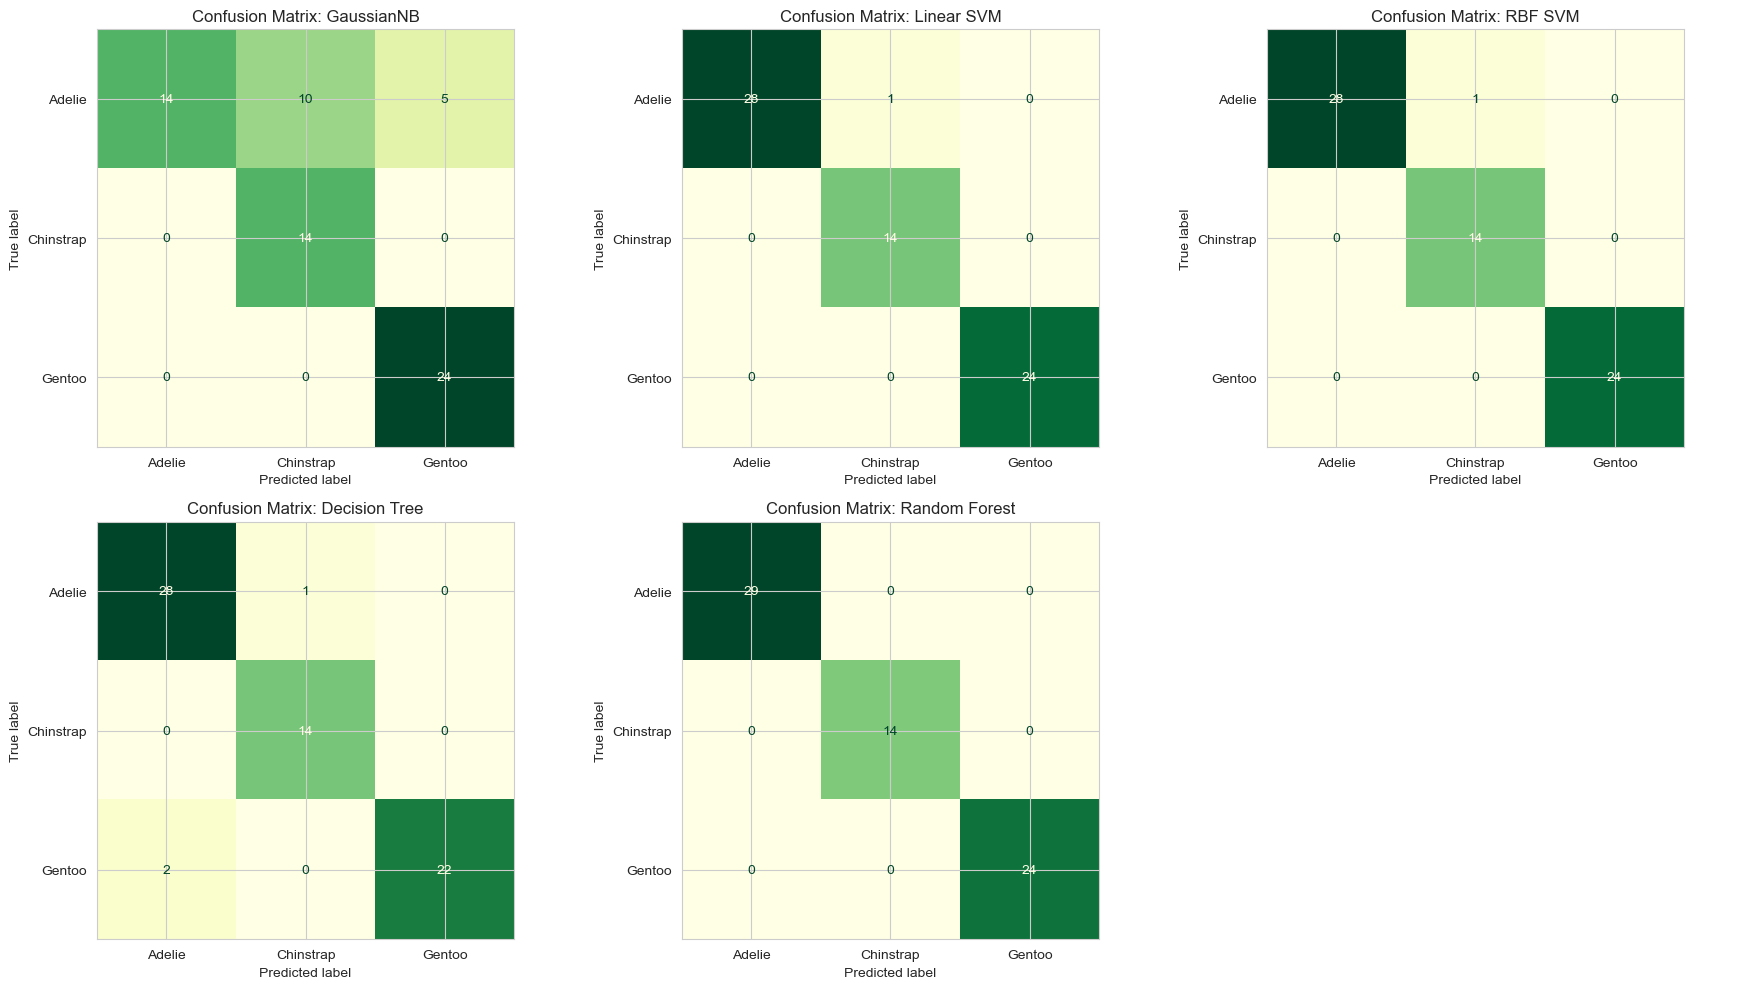

In [30]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() 
species_names = ['Adelie', 'Chinstrap', 'Gentoo']

for i, (name, model) in enumerate(models.items()):
    disp = ConfusionMatrixDisplay.from_estimator(
        model, 
        X_test_scaled, 
        y_test, 
        display_labels=species_names, 
        ax=axes[i], 
        cmap="YlGn", 
        colorbar=False
    )
    axes[i].set_title(f"Confusion Matrix: {name}")
axes[-1].axis('off')
plt.tight_layout()
plt.show()

Based on the confusion matrices, the most frequently confused species pair across almost all models is Adelie and Chinstrap, primarily due to their overlapping physical dimensions. GaussianNB struggles the most with this distinction, misclassifying nearly half of the Adelie samples. While Linear SVM and Decision Tree show high precision with only minor errors, Random Forest stands out as the most robust model, achieving a perfect diagonal matrix with zero misclassifications. Interestingly, Gentoo remains the easiest to identify across all high-performing models, confirming its status as a visually and numerically distinct species in the dataset.

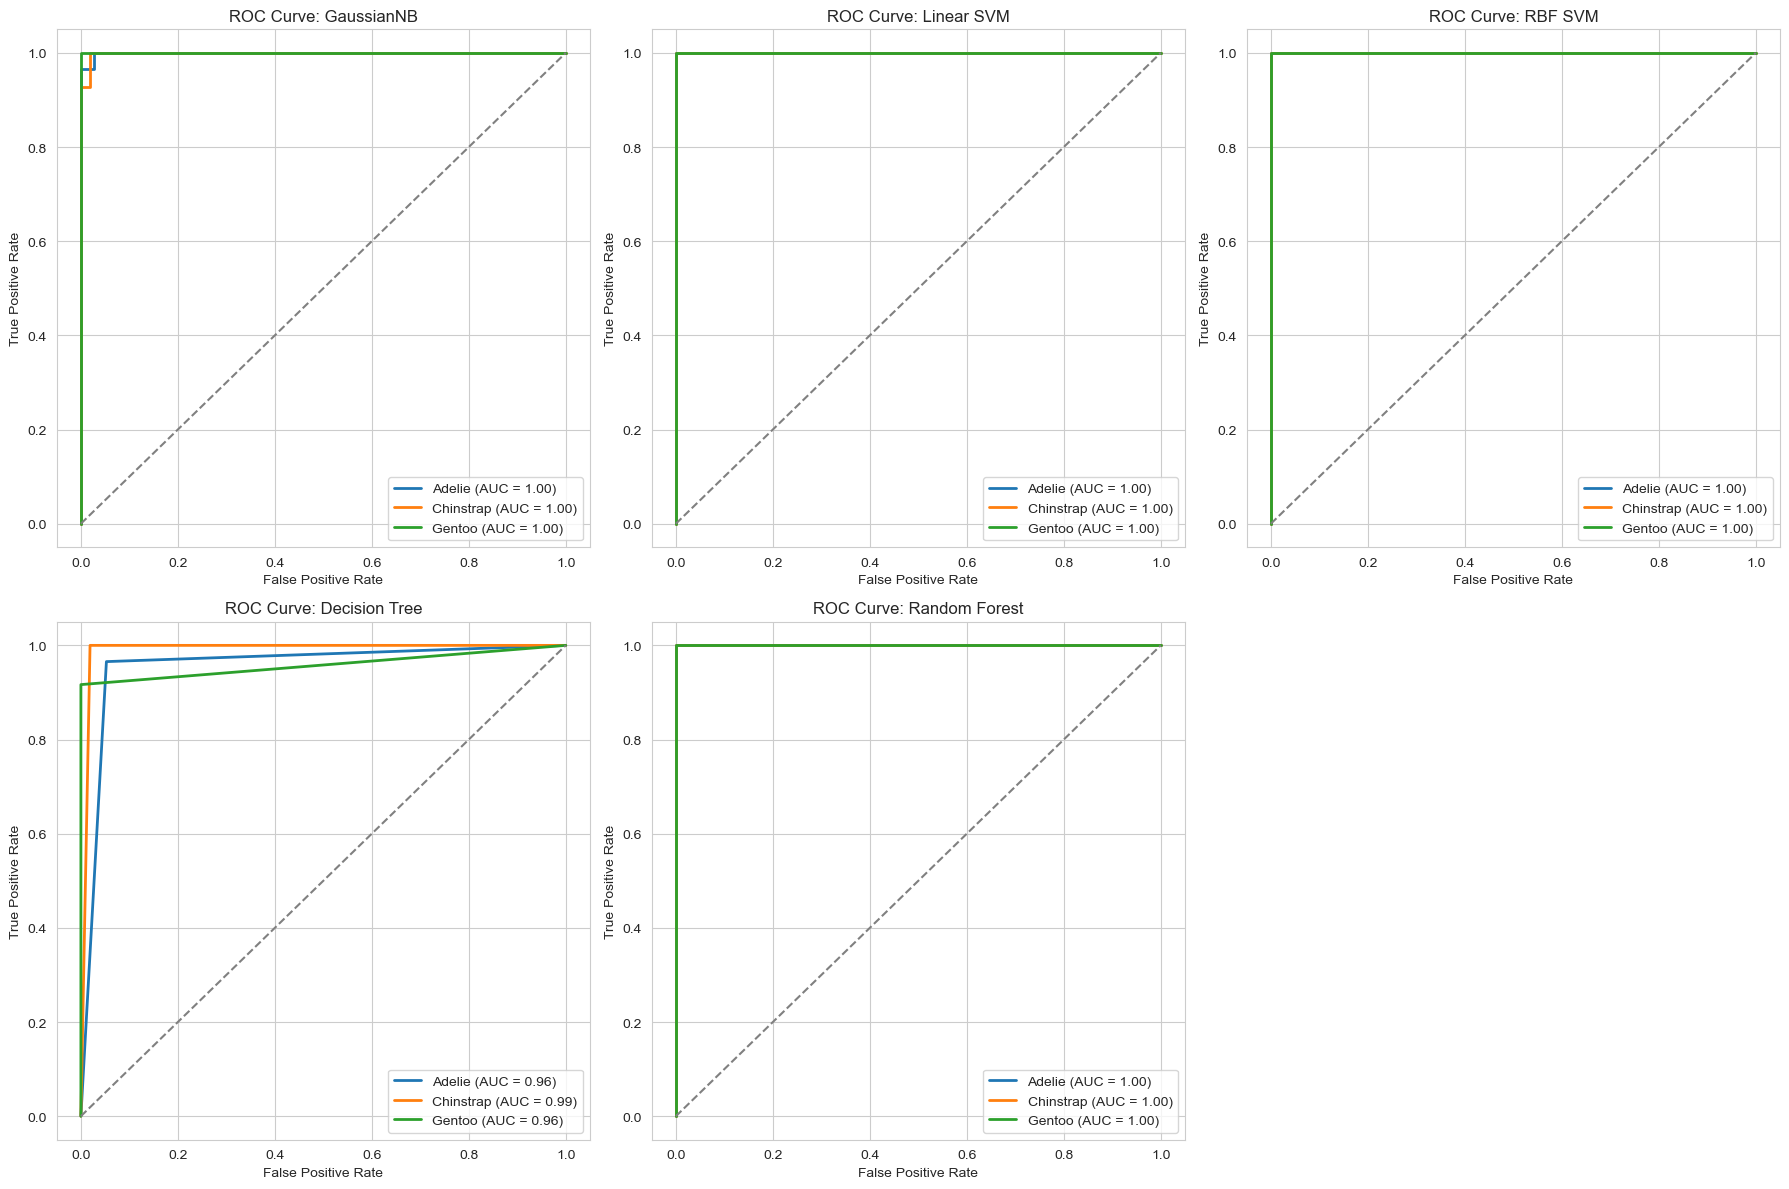

In [31]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
species_names = ['Adelie', 'Chinstrap', 'Gentoo']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    y_score = model.predict_proba(X_test_scaled)
    ax = axes[i]
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{species_names[j]} (AUC = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
    
    ax.set_title(f"ROC Curve: {name}")
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right")
axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Which model best balances precision and recall across all three species?**

The Random Forest model provides the best balance. With an F1-score of 1.00, it achieves a perfect equilibrium between Precision and Recall across all species.

**Which species pair is hardest for the models to distinguish? Why might this be the case given the features?**

The Adelie and Chinstrap pair is the hardest to distinguish.Looking at the dataset, Adelie and Chinstrap penguins have very similar body masses and flipper lengths. While Gentoo penguins are significantly larger (the "heavyweights" of the group), the overlap in physical dimensions between Adelie and Chinstrap makes them statistically "closer" in the feature space.

**Based on the confusion matrices and ROC curves, which model would you recommend?**

Based on the evidence from both the confusion matrices and the ROC curves, I recommend the Random Forest Classifier.

## Task 4: Hyperparameter Exploration

In [32]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5,            
    scoring='f1_weighted', 
    n_jobs=-1        
)
grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
y_pred_final = best_rf.predict(X_test_scaled)
print("Final Model Performance (Tuned Random Forest):")
print(classification_report(y_test, y_pred_final))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Score: 0.9961656161968262
Final Model Performance (Tuned Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



**Was the improvement significant?** 

The improvement from hyperparameter tuning was not significant, as the default Random Forest model already achieved near-perfect performance due to the high separability of the penguin species.

**Is there a risk of overfitting to the validation folds?**

Yes, there is always a slight risk that the search "memorizes" the specific validation splits. However, using 5-fold cross-validation effectively mitigates this by ensuring the chosen parameters work consistently across different data subsets.

**When is hyperparameter tuning most impactful?**

Tuning is most impactful on complex, noisy, or imbalanced datasets where default settings lead to poor performance. It is essential for moving a model from mediocre to high-performing when the underlying patterns are difficult for a "standard" model to catch.